# Desafío 1 - Análisis Multivariado

## Universidad Autónoma de Occidente
### Alejandro Meneses, Henry Rosenstiehl


### Instalación de Librerias e Imports

In [1]:
# Instalación opcional si hace falta
!pip install librosa seaborn scikit-learn open-nipals


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
pimport = None
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Situación 1
## PCA sobre características espectrales de audio

Cada canción se convierte en un vector numérico de frecuencias. Así construimos una matriz **X** donde:

- Filas = canciones o individuos.
- Columnas = bandas de frecuencia o variables.

Luego aplicamos PCA normado para reducir la dimensión y visualizar la nube de canciones en el plano PC1-PC2.

## 1.1 Extracción de Características Espectrales

### 1.1.1 Análisis Tiempo-Frecuencia mediante STFT

Para cada señal de audio se calcula su espectrograma mediante la Transformada de Fourier de Tiempo Corto (**STFT**). La idea es dividir la señal en pequeñas ventanas temporales y analizar el contenido frecuencial de cada ventana.

Para el PCA se utilizará la magnitud del espectrograma, ya que permite construir variables cuantitativas comparables entre canciones. En este notebook, cada canción se resume con el promedio de magnitud por banda de frecuencia.

In [3]:
def calcular_espectrograma_stft(path_audio, duracion=30, n_fft=2048, hop_length=512):
    """Calcula la STFT compleja y separa magnitud y fase."""
    y, sr = librosa.load(path_audio, duration=duracion, mono=True)
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    magnitud = np.abs(S)
    fase = np.angle(S)
    frecuencias = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    tiempos = librosa.frames_to_time(
        np.arange(S.shape[1]), sr=sr, hop_length=hop_length
    )
    return y, sr, S, magnitud, fase, frecuencias, tiempos

In [4]:
def extraer_vector_frecuencias(path_audio, duracion=30, n_fft=2048, hop_length=512):
    """Convierte una canción en un vector de magnitudes promedio por frecuencia."""
    _, _, _, magnitud, _, _, _ = calcular_espectrograma_stft(
        path_audio, duracion=duracion, n_fft=n_fft, hop_length=hop_length
    )
    vector = magnitud.mean(axis=1)
    return vector

### 1.2 Construcción de la Matriz de Datos

A partir de los espectrogramas se construye una matriz de datos $X \in \mathbb{R}^{n \times p}$, donde $n$ es el número de observaciones y $p$ es el número de bandas de frecuencia utilizadas como variables.

En este notebook, cada observación corresponde a una canción completa. Para cada canción se calcula la magnitud del espectrograma $|S[f,t]|$ y luego se promedia a lo largo del tiempo. Así, cada fila de $X$ contiene un vector con la magnitud promedio de cada banda de frecuencia.

In [5]:
def construir_matriz_datos(ruta_dataset, max_por_genero=None):
    """
    Construye la matriz X.
    Se espera una estructura tipo GTZAN:
    ruta_dataset/blues/*.wav
    ruta_dataset/classical/*.wav
    etc.
    """
    X = []
    generos = []
    archivos = []

    for genero in sorted(os.listdir(ruta_dataset)):
        carpeta = os.path.join(ruta_dataset, genero)
        if not os.path.isdir(carpeta):
            continue

        audios = [a for a in sorted(os.listdir(carpeta)) if a.lower().endswith((".wav", ".au", ".mp3"))]
        if max_por_genero is not None:
            audios = audios[:max_por_genero]

        for archivo in audios:
            path = os.path.join(carpeta, archivo)
            try:
                X.append(extraer_vector_frecuencias(path))
                generos.append(genero)
                archivos.append(archivo)
            except Exception as e:
                print(f"No se pudo procesar {path}: {e}")

    X = np.array(X)
    return X, pd.DataFrame({"archivo": archivos, "genero": generos})

## 1.3. Cargar el dataset


In [6]:
ruta_dataset = "archive/genres"  # cambiar según la carpeta

X, meta = construir_matriz_datos(ruta_dataset, max_por_genero=None)

display(Markdown(f"> Dimensión de X: {X.shape}"))
meta.head()

NameError: name 'Markdown' is not defined

## 1.4. Estadísticos descriptivos básicos

Antes del PCA, miramos la forma general de las variables: medias, desviaciones estándar, mínimos y máximos.

In [ ]:
df_freq = pd.DataFrame(X, columns=[f"freq_{i}" for i in range(X.shape[1])])
resumen = df_freq.describe().T[["mean", "std", "min", "max"]]
resumen.head(10)

,mean,std,min,max
freq_0,1.585831,2.588204,0.015385,31.241837
freq_1,1.455606,1.934261,0.010827,27.877838
freq_2,2.065686,2.450887,0.009711,17.811153
freq_3,5.431329,6.718586,0.017554,50.191685
freq_4,11.749763,13.437912,0.026641,91.641113
freq_5,16.957232,16.386932,0.062946,91.386864
freq_6,18.334488,15.386399,0.069070,104.130829
freq_7,17.704212,14.625978,0.092041,146.157867
freq_8,16.637896,13.119179,0.127764,76.727295
freq_9,15.759619,11.943995,0.109404,87.131706


## 1.5. PCA normado

Como las frecuencias pueden tener escalas/amplitudes distintas, usamos PCA normado: cada variable queda con media 0 y desviación estándar 1. Esto equivale a trabajar con la matriz de correlaciones.

In [ ]:
scaler = StandardScaler()
Z = scaler.fit_transform(X)

pca = PCA()
coord = pca.fit_transform(Z)

eigenvalores = pca.explained_variance_
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

tabla_varianza = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(var_exp))],
    "autovalor": eigenvalores,
    "varianza_explicada": var_exp,
    "varianza_acumulada": var_acum
})

tabla_varianza.head(10)

,componente,autovalor,varianza_explicada,varianza_acumulada
0,PC1,677.421021,0.660238,0.660238
1,PC2,142.213959,0.138607,0.798845
2,PC3,38.432663,0.037458,0.836302
3,PC4,17.427256,0.016985,0.853288
4,PC5,15.831869,0.015430,0.868718
5,PC6,10.507718,0.010241,0.878959
6,PC7,8.063630,0.007859,0.886818
7,PC8,7.669882,0.007475,0.894293
8,PC9,7.528725,0.007338,0.901631
9,PC10,4.634529,0.004517,0.906148


## 1.6. Gráfico de sedimentación

Este gráfico ayuda a decidir cuántos componentes retener. Buscamos un punto donde la ganancia adicional de varianza empiece a disminuir claramente.

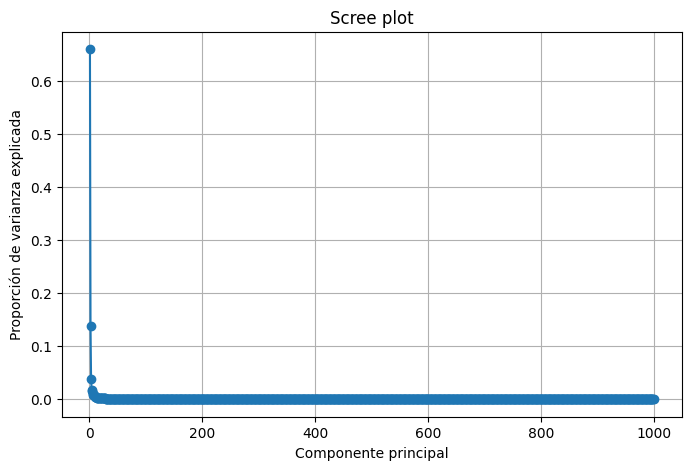

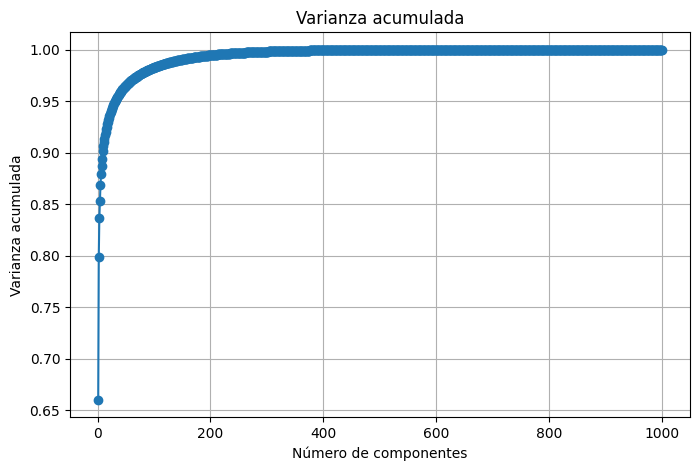

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_exp) + 1), var_exp, marker="o")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.title("Scree plot")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada")
plt.grid(True)
plt.show()

El gráfico de sedimentación muestra una caída muy fuerte en las primeras componentes principales. La primera componente concentra la mayor parte de la variabilidad de los datos, lo que indica que existe una dirección dominante en la estructura espectral de las canciones. La segunda componente todavía aporta información adicional relevante, pero a partir de la tercera o cuarta componente la contribución marginal de varianza es muy baja.

Por tanto, una representación en pocas dimensiones, especialmente usando PC1 y PC2, conserva una parte importante de la información original y permite visualizar la estructura general de las canciones. El aplanamiento rápido de la curva sugiere que muchas bandas de frecuencia están correlacionadas entre sí o contienen información redundante para el análisis PCA.


## 1.7. Nube de individuos: canciones en PC1 y PC2

Aquí cada punto es una canción. Si varios puntos del mismo género quedan cerca, eso sugiere que comparten estructura espectral.

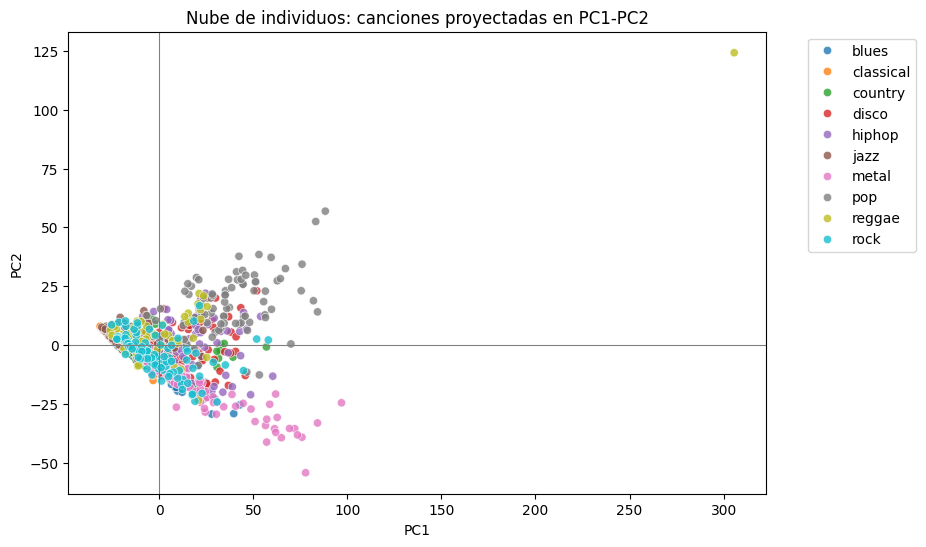

In [ ]:
df_pca = pd.DataFrame({
    "PC1": coord[:, 0],
    "PC2": coord[:, 1],
    "genero": meta["genero"],
    "archivo": meta["archivo"]
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="genero", alpha=0.8)
plt.title("Nube de individuos: canciones proyectadas en PC1-PC2")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 1.8. Cargas de variables

Las cargas indican qué frecuencias participan más en cada componente. Valores positivos o negativos grandes, en valor absoluto, significan mayor influencia en la construcción del eje.

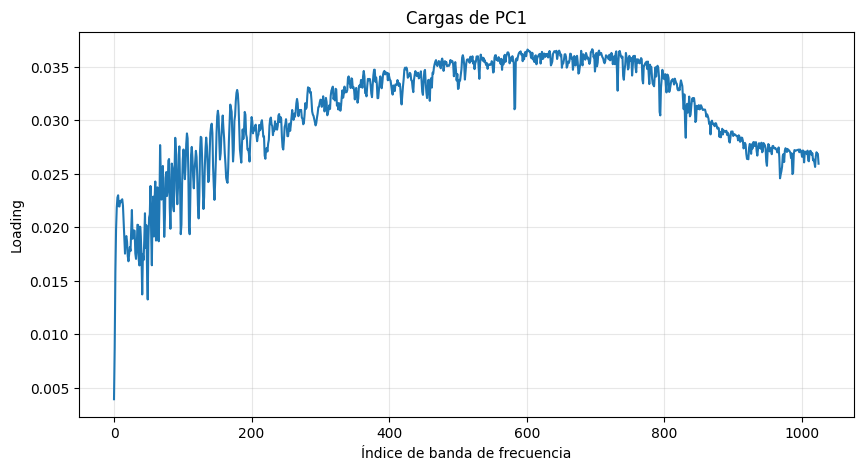

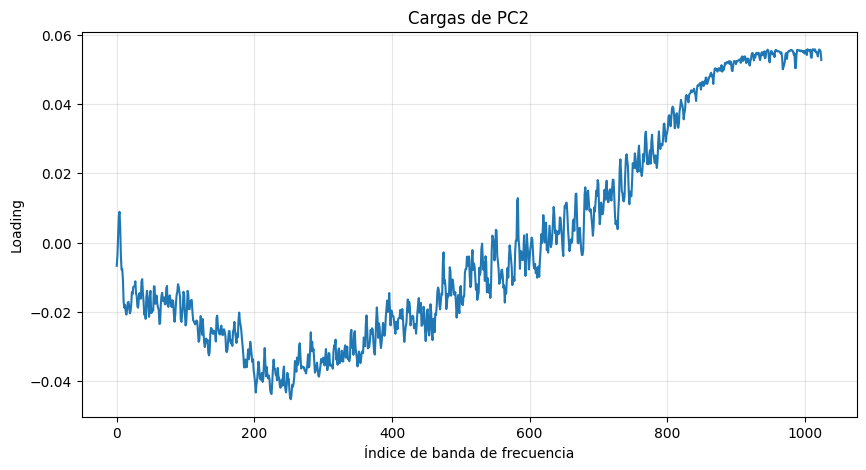

In [ ]:
loadings = pca.components_

plt.figure(figsize=(10, 5))
plt.plot(loadings[0])
plt.title("Cargas de PC1")
plt.xlabel("Índice de banda de frecuencia")
plt.ylabel("Loading")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(loadings[1])
plt.title("Cargas de PC2")
plt.xlabel("Índice de banda de frecuencia")
plt.ylabel("Loading")
plt.grid(True, alpha=0.3)
plt.show()

# Situación 3

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from open_nipals.nipalsPCA import NipalsPCA

### Pequeño EDA del dataset

In [ ]:
df = pd.read_csv("dataset_GENOMICS 100.csv")
display(df.head())
display(df.shape)
display(Markdown("Datos Nulos: {}".format(df.isna().sum().sum())))

,Muestra_ID,Gen_1,Gen_2,Gen_3,Gen_4,Gen_5,Gen_6,Gen_7,Gen_8,Gen_9,...,Gen_1991,Gen_1992,Gen_1993,Gen_1994,Gen_1995,Gen_1996,Gen_1997,Gen_1998,Gen_1999,Gen_2000
0,Tipo001_Muestra1,-0.926129,-1.299938,3.486351,-1.102222,-0.428913,-0.747000,NaN,-1.086151,0.995133,...,-0.043145,-0.111840,-0.375548,-0.528212,0.759602,-0.026776,-0.207460,-0.388127,1.968288,-1.681775
1,Tipo001_Muestra2,-0.972536,-1.477558,3.135393,-0.524263,0.094519,-1.368749,1.573978,-1.184006,0.696335,...,1.199829,2.141636,-0.066823,0.252472,1.212322,-0.998419,-0.540939,-0.630091,-0.617466,0.818629
2,Tipo001_Muestra3,-0.825555,-0.609148,3.016207,-1.031508,-0.283858,-1.056996,2.222693,-0.780960,0.677335,...,-1.041196,1.455374,-0.463369,-0.304951,-0.087723,-0.266249,0.382303,-1.026754,-0.542969,-1.480541
3,Tipo001_Muestra4,-0.625623,-0.899633,3.695983,-1.190333,0.010032,-0.366977,1.924482,-1.271057,0.636734,...,0.116033,-2.503982,1.404051,2.276509,0.739348,1.173409,1.259947,-0.637688,0.502837,-2.114035
4,Tipo001_Muestra5,-0.894942,-1.002972,3.126358,-1.179200,-0.586038,-0.545477,1.824211,-0.682414,0.717442,...,2.530071,-0.371028,-1.949529,1.374980,-0.520373,-1.265650,-0.227383,-0.253384,0.018274,-0.367521


(500, 2001)

Datos Nulos: 50000

El conjunto de datos presenta valores faltantes (~5%), lo cual impide aplicar directamente el PCA, ya que esta técnica requiere una matriz completa de datos.

### Extracción del subtipo

Se crea una columna con el subtipo de cada Muestra, donde se extrae de la `Muestra_ID`

In [ ]:
df["Subtipo"] = df["Muestra_ID"].str.split("_").str[0]
df[["Muestra_ID", "Subtipo"]].head()

,Muestra_ID,Subtipo
0,Tipo001_Muestra1,Tipo001
1,Tipo001_Muestra2,Tipo001
2,Tipo001_Muestra3,Tipo001
3,Tipo001_Muestra4,Tipo001
4,Tipo001_Muestra5,Tipo001


In [ ]:
X = df.drop(columns=["Muestra_ID", "Subtipo"])
labels = df["Subtipo"]

### Imputación por Media

Se imputan los datos hasta obtener 0 valores nulos en el dataset, utiliazndo la media de los datos para la imputación de estos.

In [ ]:
imputer = SimpleImputer(strategy="mean")

X_media = imputer.fit_transform(X)
X_media = pd.DataFrame(X_media, columns=X.columns)

display(Markdown("Datos Nulos: {}".format(X_media.isna().sum().sum())))

Datos Nulos: 0

### Estandarizar Datos

In [ ]:
scaler = StandardScaler()

X_media_scaled = scaler.fit_transform(X_media)

### PCA de Media

In [ ]:
pca_media = PCA(n_components=2)

X_pca_media = pca_media.fit_transform(X_media_scaled)
df_pca_media = pd.DataFrame({
    "PC1": X_pca_media[:, 0],
    "PC2": X_pca_media[:, 1],
    "Subtipo": labels
})

df_pca_media.head()

,PC1,PC2,Subtipo
0,0.672764,-3.030662,Tipo001
1,-2.410626,1.085220,Tipo001
2,-1.349956,0.186532,Tipo001
3,-2.509156,4.222311,Tipo001
4,-0.458586,1.984057,Tipo001


### Resultados PCA Media

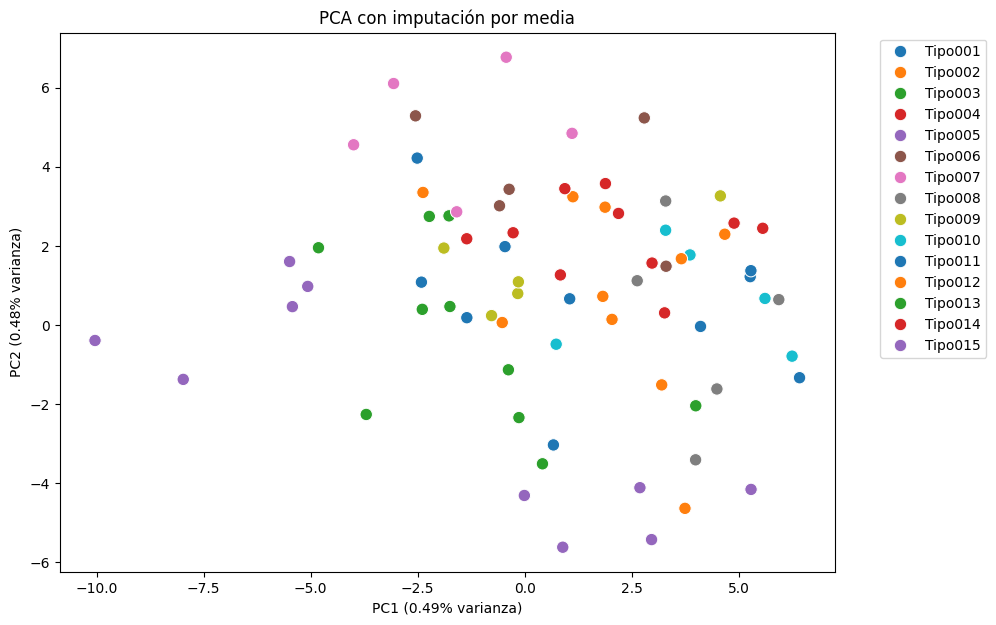

In [ ]:
subtipos_mostrar = labels.unique()[:15]

df_pca_media_plot = df_pca_media[
    df_pca_media["Subtipo"].isin(subtipos_mostrar)
]

plt.figure(figsize=(10, 7))
palette = dict(zip(subtipos_mostrar, sns.color_palette(n_colors=len(subtipos_mostrar))))

sns.scatterplot(
    data=df_pca_media_plot,
    x="PC1",
    y="PC2",
    hue="Subtipo",
    palette=palette,
    s=80
)

plt.title("PCA con imputación por media")
plt.xlabel(f"PC1 ({pca_media.explained_variance_ratio_[0]*100:.2f}% varianza)")
plt.ylabel(f"PC2 ({pca_media.explained_variance_ratio_[1]*100:.2f}% varianza)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
var_media_pc1 = pca_media.explained_variance_ratio_[0] * 100
var_media_pc2 = pca_media.explained_variance_ratio_[1] * 100

var_total = var_media_pc1 + var_media_pc2

print(f"PC1 explica: {var_media_pc1:.2f}%")
print(f"PC2 explica: {var_media_pc2:.2f}%")
print(f"PC1 + PC2 explican: {var_total:.2f}%")

PC1 explica: 0.49%
PC2 explica: 0.48%
PC1 + PC2 explican: 0.97%


### Imputación por K-NN

Se imputan los datos hasta obtener 0 valores nulos en el dataset, utilizando K-NN (en este caso, `k = 10`) de los datos para la imputación de estos.

In [ ]:
imputer_knn = KNNImputer(n_neighbors=10)
X_knn = imputer_knn.fit_transform(X)
X_knn = pd.DataFrame(X_knn, columns=X.columns)

In [ ]:
scaler = StandardScaler()
X_knn_scaled = scaler.fit_transform(X_knn)

In [ ]:
pca_knn = PCA(n_components=2)
X_pca_knn = pca_knn.fit_transform(X_knn_scaled)

df_pca_knn = pd.DataFrame({
    "PC1": X_pca_knn[:, 0],
    "PC2": X_pca_knn[:, 1],
    "Subtipo": labels
})

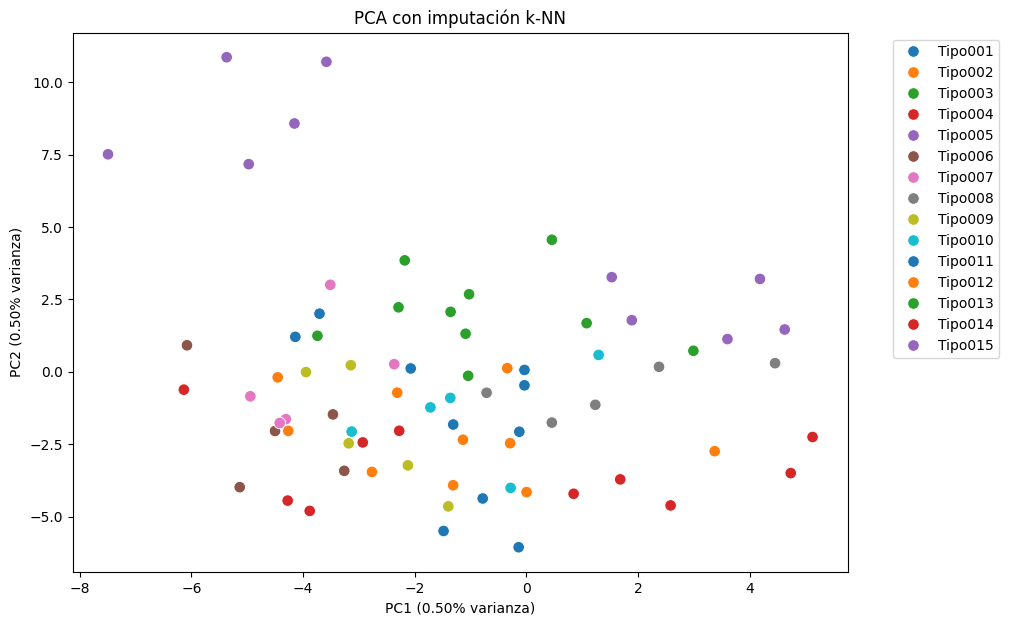

In [ ]:
subtipos_mostrar = labels.unique()[:15]

df_plot_knn = df_pca_knn[
    df_pca_knn["Subtipo"].isin(subtipos_mostrar)
]
plt.figure(figsize=(10, 7))
palette = dict(zip(subtipos_mostrar, sns.color_palette(n_colors=len(subtipos_mostrar))))

sns.scatterplot(
    data=df_plot_knn,
    x="PC1",
    y="PC2",
    hue="Subtipo",
    palette=palette,
    s=70
)

plt.title("PCA con imputación k-NN")

plt.xlabel(f"PC1 ({pca_knn.explained_variance_ratio_[0]*100:.2f}% varianza)")
plt.ylabel(f"PC2 ({pca_knn.explained_variance_ratio_[1]*100:.2f}% varianza)")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
var_knn_pc1 = pca_knn.explained_variance_ratio_[0] * 100
var_knn_pc2 = pca_knn.explained_variance_ratio_[1] * 100

print(f"PC1 explica: {var_knn_pc1:.2f}%")
print(f"PC2 explica: {var_knn_pc2:.2f}%")
print(f"Total explica: {var_knn_pc1 + var_knn_pc2:.2f}%")

PC1 explica: 0.50%
PC2 explica: 0.50%
Total explica: 1.00%


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo_nipals = NipalsPCA(n_components=2)
X_pca_nipals = modelo_nipals.fit_transform(X_scaled)

df_pca_nipals = pd.DataFrame({
    "PC1": X_pca_nipals[:, 0],
    "PC2": X_pca_nipals[:, 1],
    "Subtipo": labels
})

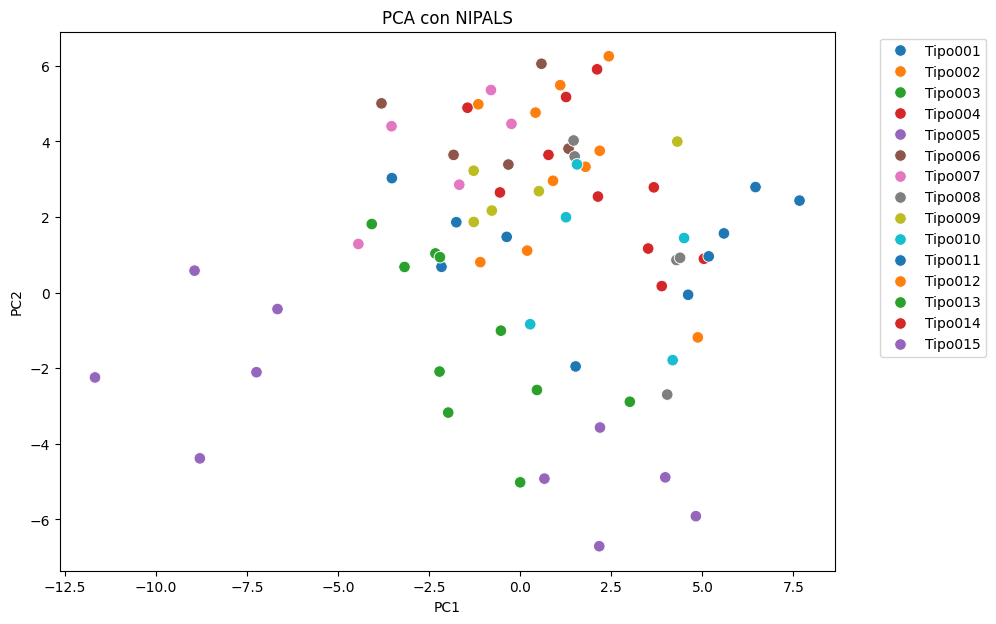

In [ ]:
subtipos_mostrar = labels.unique()[:15]

df_plot_nipals = df_pca_nipals[
    df_pca_nipals["Subtipo"].isin(subtipos_mostrar)
]

plt.figure(figsize=(10, 7))
palette = dict(zip(subtipos_mostrar, sns.color_palette(n_colors=len(subtipos_mostrar))))
sns.scatterplot(
    data=df_plot_nipals,
    x="PC1",
    y="PC2",
    hue="Subtipo",
    palette=palette,
    s=70
)

plt.title("PCA con NIPALS")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
var_nipals_pc1 = None
var_nipals_pc2 = None

if hasattr(modelo_nipals, "explained_variance_ratio_"):
    var_nipals_pc1 = modelo_nipals.explained_variance_ratio_[0]
    var_nipals_pc2 = modelo_nipals.explained_variance_ratio_[1]
    print(f"PC1 explica: {var_nipals_pc1:.2f}%")
    print(f"PC2 explica: {var_nipals_pc2:.2f}%")
    print(f"PC1 + PC2 explican: {var_nipals_pc1 + var_nipals_pc2:.2f}%")


PC1 explica: 0.01%
PC2 explica: 0.01%
PC1 + PC2 explican: 0.01%


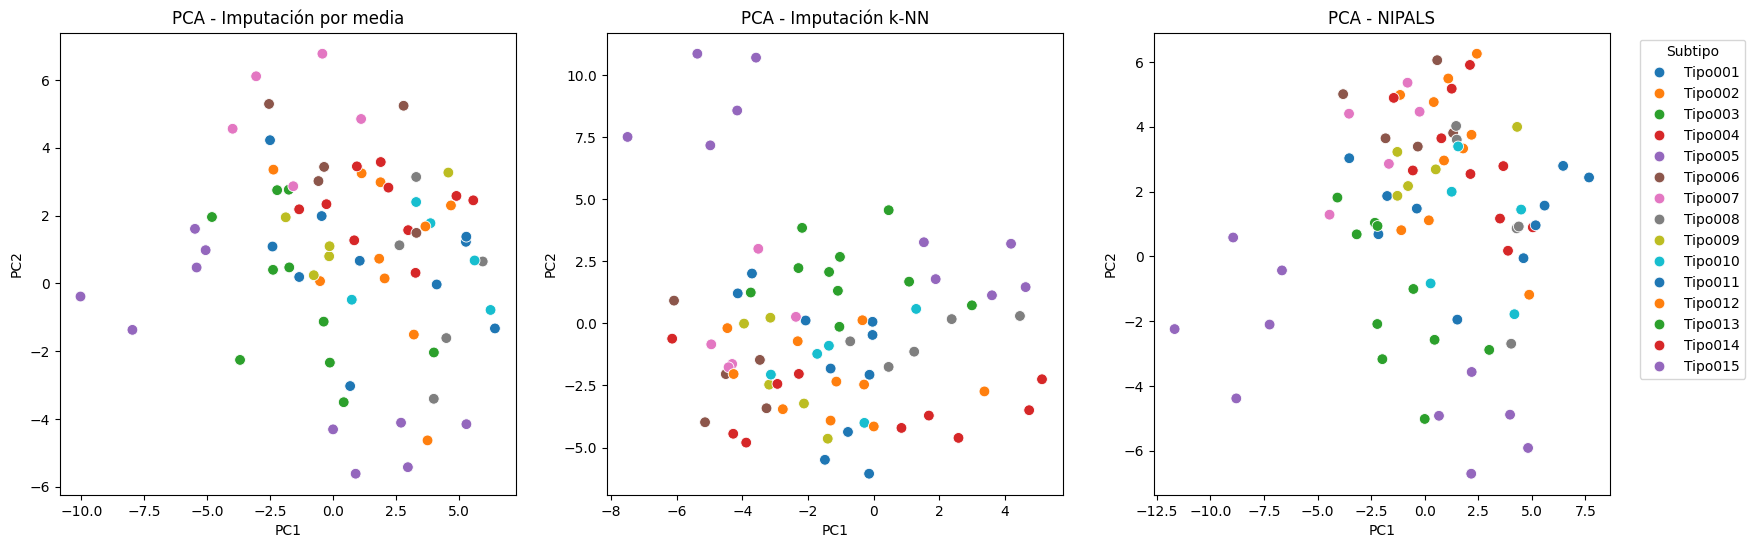

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

subtipos_mostrar = labels.unique()[:15]

df_plot_media = df_pca_media[df_pca_media["Subtipo"].isin(subtipos_mostrar)]
df_plot_knn = df_pca_knn[df_pca_knn["Subtipo"].isin(subtipos_mostrar)]
df_plot_nipals = df_pca_nipals[df_pca_nipals["Subtipo"].isin(subtipos_mostrar)]
palette = dict(zip(subtipos_mostrar, sns.color_palette(n_colors=len(subtipos_mostrar))))

axes[0].set_title("PCA - Imputación por media")
sns.scatterplot(
    data=df_plot_media,
    x="PC1",
    y="PC2",
    hue="Subtipo",
    palette=palette,
    ax=axes[0],
    legend=False,
    s=60
)

axes[1].set_title("PCA - Imputación k-NN")
sns.scatterplot(
    data=df_plot_knn,
    x="PC1",
    y="PC2",
    hue="Subtipo",
    palette=palette,
    ax=axes[1],
    legend=False,
    s=60
)

axes[2].set_title("PCA - NIPALS")
sns.scatterplot(
    data=df_plot_nipals,
    x="PC1",
    y="PC2",
    hue="Subtipo",
    palette=palette,
    ax=axes[2],
    legend=True,
    s=60
)

axes[2].legend(title="Subtipo", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
import pandas as pd

var_media_pc1 = pca_media.explained_variance_ratio_[0]
var_media_pc2 = pca_media.explained_variance_ratio_[1]

var_knn_pc1 = pca_knn.explained_variance_ratio_[0]
var_knn_pc2 = pca_knn.explained_variance_ratio_[1]

if hasattr(modelo_nipals, "explained_variance_ratio_"):
    var_nipals_pc1 = modelo_nipals.explained_variance_ratio_[0]
    var_nipals_pc2 = modelo_nipals.explained_variance_ratio_[1]
else:
    var_nipals_pc1 = None
    var_nipals_pc2 = None

df_var = pd.DataFrame({
    "Metodo": ["Media", "k-NN", "NIPALS"],
    "PC1 (%)": [
        var_media_pc1 * 100,
        var_knn_pc1 * 100,
        var_nipals_pc1 * 100 if var_nipals_pc1 else None
    ],
    "PC2 (%)": [
        var_media_pc2 * 100,
        var_knn_pc2 * 100,
        var_nipals_pc2 * 100 if var_nipals_pc2 else None
    ]
})

df_var["Total PC1+PC2 (%)"] = df_var["PC1 (%)"] + df_var["PC2 (%)"]

display(df_var)

,Metodo,PC1 (%),PC2 (%),Total PC1+PC2 (%)
0,Media,0.489865,0.483359,0.973224
1,k-NN,0.504198,0.500320,1.004518
2,NIPALS,0.526468,0.521519,1.047987


Con base en los resultados obtenidos, se recomienda al equipo de *VALLE-GENOMICS 100* utilizar el enfoque basado en NIPALS para el análisis de componentes principales en presencia de datos faltantes.

Aunque la proporción de varianza explicada por las primeras componentes es similar entre los tres métodos evaluados, el análisis visual muestra que NIPALS logra una mejor preservación de la estructura de los datos, permitiendo una mayor diferenciación entre los subtipos tumorales. A diferencia de la imputación por media, que reduce la variabilidad y distorsiona los datos, y de k-NN, que si bien mejora la estructura local introduce valores estimados, NIPALS trabaja directamente con los datos disponibles sin necesidad de imputación previa, evitando la introducción de sesgos artificiales.

En consecuencia, NIPALS ofrece una representación más fiel de la geometría original del conjunto de datos, lo que resulta fundamental en estudios genómicos donde la identificación de patrones sutiles entre subtipos puede ser crítica para la clasificación y el desarrollo de tratamientos personalizados.